![](https://github.com/destination-earth/DestinE-DataLake-Lab/blob/main/img/DestinE-banner.jpg?raw=true)



# DEDL - HDA Tutorial - access HydroMet

**Author**: EUMETSAT <br>
**Copyright**: 2024 EUMETSAT <br>
**Licence**: MIT <br>
**Modified by**: chartick

<div class="alert alert-block alert-warning">
<b> Prerequisites: </b>
<li> For Data access : <a href="https://platform.destine.eu/"> DestinE user account and access to restricted datasets</a> </li>
</div>

### Import the relevant modules

In [4]:
pip install --user --quiet destinelab==1.14


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import requests
import json
from getpass import getpass
from tqdm import tqdm
import xarray as xr

import destinelab as deauth


### Define some constants for the API URL




In [20]:
# Define the collection to be used
COLLECTION_ID = "EO.DWD.STAT.HYDROMET_EXTREMES"

# Core API
HDA_API_URL = "https://hda.data.destination-earth.eu"

# STAC API
## Core
STAC_API_URL = f"{HDA_API_URL}/stac/v2"

## Collections
COLLECTIONS_URL = f"{STAC_API_URL}/collections"
COLLECTION_BY_ID_URL = f"{COLLECTIONS_URL}/{COLLECTION_ID}"

## Items
COLLECTION_ITEMS_URL = f"{COLLECTIONS_URL}/{COLLECTION_ID}/items"

## Item Search
SEARCH_URL = f"{STAC_API_URL}/search"

## HTTP Success
HTTP_SUCCESS_CODE = 200

## Authenticate

In [ ]:
DESP_USERNAME = input("Please input your DESP username or email: ")
DESP_PASSWORD = getpass("Please input your DESP password: ")

auth = deauth.AuthHandler(DESP_USERNAME, DESP_PASSWORD)
access_token = auth.get_token()
if access_token is not None:
    print("DEDL/DESP Access Token Obtained Successfully")
else:
    print("Failed to Obtain DEDL/DESP Access Token")

auth_headers = {"Authorization": f"Bearer {access_token}"}

In [8]:
auth_headers = {"Authorization": f"Bearer {access_token}"}

### Discover data - Authenticated

Once authenticated, we can discover the collection.

In [ ]:
response = requests.get(COLLECTION_BY_ID_URL, headers=auth_headers)

# JSON(response.json(), expanded=False)
print(json.dumps(response.json(), indent=4))

## Search

Once a collection is selected, you can search for items that match the specified input filters and order the results.


In [ ]:
COLLECTION_ID = "EO.DWD.STAT.HYDROMET_EXTREMES"
BODY = {
    "collections": [
        COLLECTION_ID,
    ],
    "datetime": "1989-01-01T00:00:00Z/2050-12-31T00:00:00Z",
    "bbox": [-180, -90, 180, 90],
    "sortby": [{"field": "datetime", "direction": "desc"}],
    "limit": 100,
}


r = requests.post(SEARCH_URL, json=BODY, headers=auth_headers)
#r = requests.post(SEARCH_URL, headers=auth_headers)
if r.status_code != 200:
    (print(r.text))
r.raise_for_status()

# JSON(response.json(), expanded=False)
print(json.dumps(r.json(), indent=4))

## Download

Once we obtained the search results, we can download the returned data.

In [ ]:
# select the first item in the result to download
product = r.json()["features"][1]

# DownloadLink is an asset representing the whole product
download_url = product["assets"]["downloadLink"]["href"]
print("Download URL:", download_url)

ITEM_ID = product["id"]
print("Item ID:", ITEM_ID)

response = requests.get(download_url, stream=True, headers=auth_headers)

total_size = int(response.headers.get("Content-Length", 0))


# If the request was successful, download the file
if response.status_code == HTTP_SUCCESS_CODE:

    print("Downloading ...")
    filename = ITEM_ID + ".zip"

    # Show progress bar if size is known
    with open(filename, "wb") as f, tqdm(
        total=total_size, unit="B", unit_scale=True, desc="Downloading"
    ) as progress_bar:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)
                f.flush()
                progress_bar.update(len(chunk))  # Update progress bar

else:
    print("Request Unsuccessful! Error-Code: {}".format(response.status_code))



## Download single files

It is also possible to download single files.

In [ ]:
url = product["assets"]["1990_01_01_T00_00_to_2014_01_01_T00_00_DDF.nc"]["href"]


local_file = "file.nc"

# download
with requests.get(url, stream=True) as r:
    r.raise_for_status()
    with open(local_file, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)




#Display the downloaded file

The downloaded file can be directly visualised with xarray

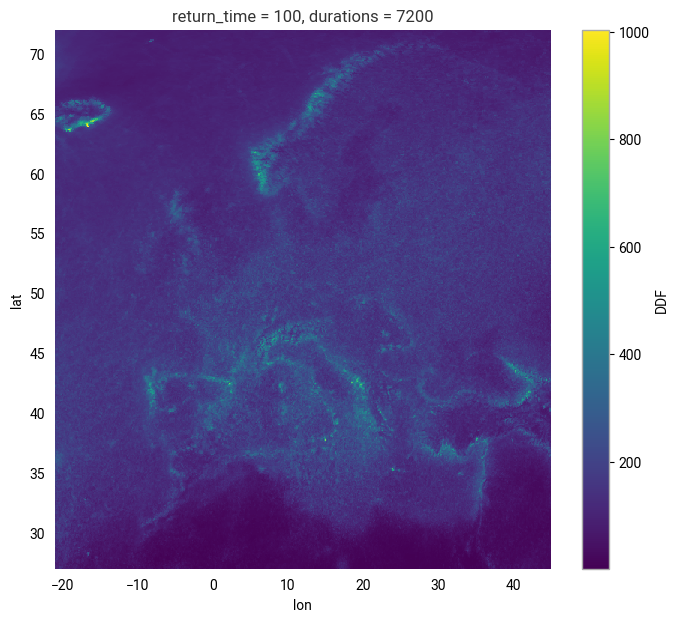

In [21]:
ds = xr.open_dataset(local_file)

return_year = 100
duration = 7200

ds = ds.DDF.sel(return_time = return_year, durations = duration)
ds.plot()